# 9. Image Matching

## Table of Contents
1. [Libraries](#libraries)
1. [ORB Matching](#orb)
1. [SIFT Matching](#sift)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [1]:
import cv2 
import matplotlib.pyplot as plt
import numpy as np

# ORB (Oriented FAST and Rotated BRIEF) <a class="anchor" id="orb" ></a>

- Developed at OpenCV labs by Ethan Rublee, Vincent Rabaud, Kurt Konolige, and Gary R. Bradski in 2011
- Efficient and viable alternative to SIFT and SURF (patented algorithms)
- ORB is free to use
- Feature detection
- ORB builds on FAST keypoint detector + BRIEF descriptor

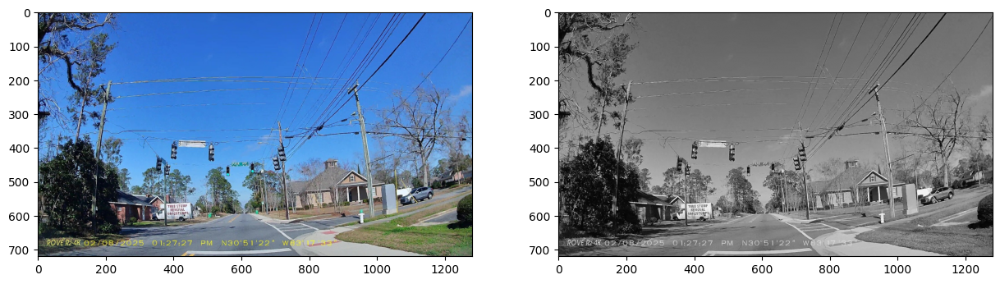

In [2]:
#reading image
img = cv2.imread('data/escena_1.jpg')  
img_color = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_color)
plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap="gray")

### Create test image by adding Scale Invariance and Rotational Invariance

In [3]:
test_image = cv2.pyrDown(img_color)
test_image = cv2.pyrDown(test_image)
num_rows, num_cols = test_image.shape[:2]

rotation_matrix = cv2.getRotationMatrix2D((num_cols/2, num_rows/2), 30, 1)
test_image = cv2.warpAffine(test_image, rotation_matrix, (num_cols, num_rows))

test_gray = cv2.cvtColor(test_image, cv2.COLOR_RGB2GRAY)

### Display traning image and testing image

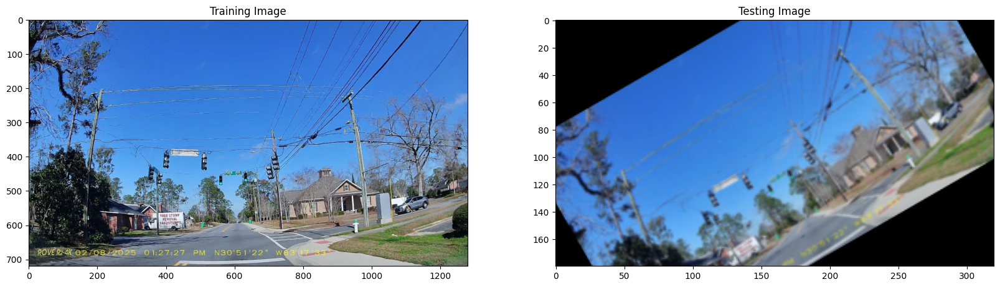

In [4]:
fx, plots = plt.subplots(1, 2, figsize=(20,10))

plots[0].set_title("Training Image")
plots[0].imshow(img_color)

plots[1].set_title("Testing Image")
plots[1].imshow(test_image)

### ORB

In [5]:
orb = cv2.ORB_create()

Number of Keypoints Detected In The Training Image:  500
Number of Keypoints Detected In The Query Image:  352


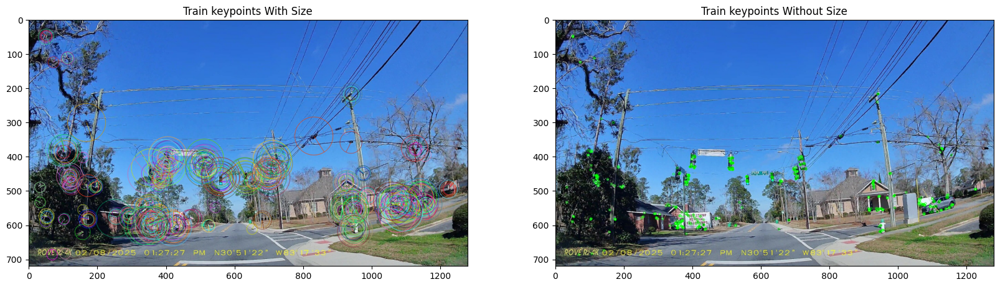

In [6]:
train_keypoints, train_descriptor = orb.detectAndCompute(img_color, None)
test_keypoints, test_descriptor = orb.detectAndCompute(test_gray, None)

keypoints_without_size = np.copy(img_color)
keypoints_with_size = np.copy(img_color)

cv2.drawKeypoints(img_color, train_keypoints, keypoints_without_size, color = (0, 255, 0))

cv2.drawKeypoints(img_color, train_keypoints, keypoints_with_size, flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Display image with and without keypoints size
fx, plots = plt.subplots(1, 2, figsize=(20,10))

plots[0].set_title("Train keypoints With Size")
plots[0].imshow(keypoints_with_size, cmap='gray')

plots[1].set_title("Train keypoints Without Size")
plots[1].imshow(keypoints_without_size, cmap='gray')

# Print the number of keypoints detected in the training image
print("Number of Keypoints Detected In The Training Image: ", len(train_keypoints))

# Print the number of keypoints detected in the query image
print("Number of Keypoints Detected In The Query Image: ", len(test_keypoints))

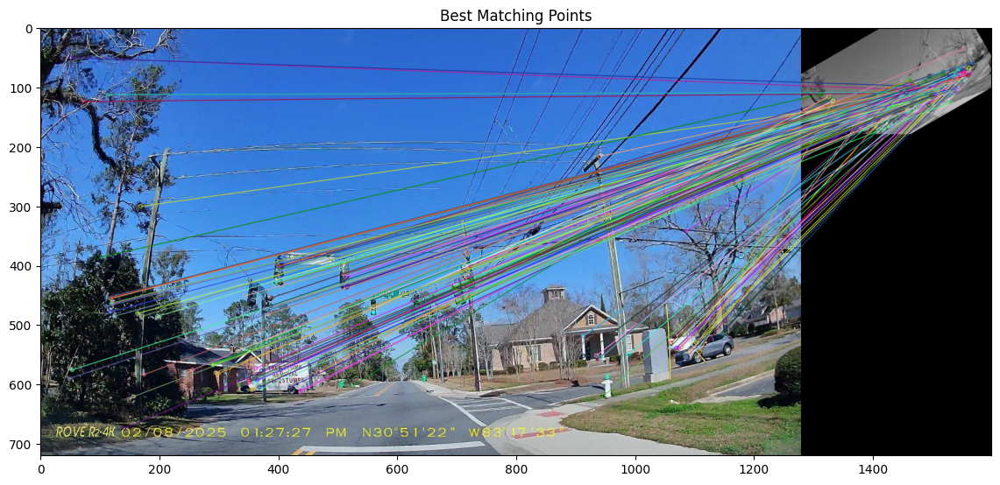


Number of Matching Keypoints Between The Training and Query Images:  130


In [7]:

# Create a Brute Force Matcher object.
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck = True)

# Perform the matching between the ORB descriptors of the training image and the test image
matches = bf.match(train_descriptor, test_descriptor)

# The matches with shorter distance are the ones we want.
matches = sorted(matches, key = lambda x : x.distance)

result = cv2.drawMatches(img_color, train_keypoints, test_gray, test_keypoints, matches, test_gray, flags = 2)

# Display the best matching points
plt.rcParams['figure.figsize'] = [14.0, 7.0]
plt.title('Best Matching Points')
plt.imshow(result)
plt.show()

# Print total number of matching points between the training and query images
print("\nNumber of Matching Keypoints Between The Training and Query Images: ", len(matches))

## SIFT Matching (Scale Invariant Feature Transform) <a class="anchor" id="sift" ></a>

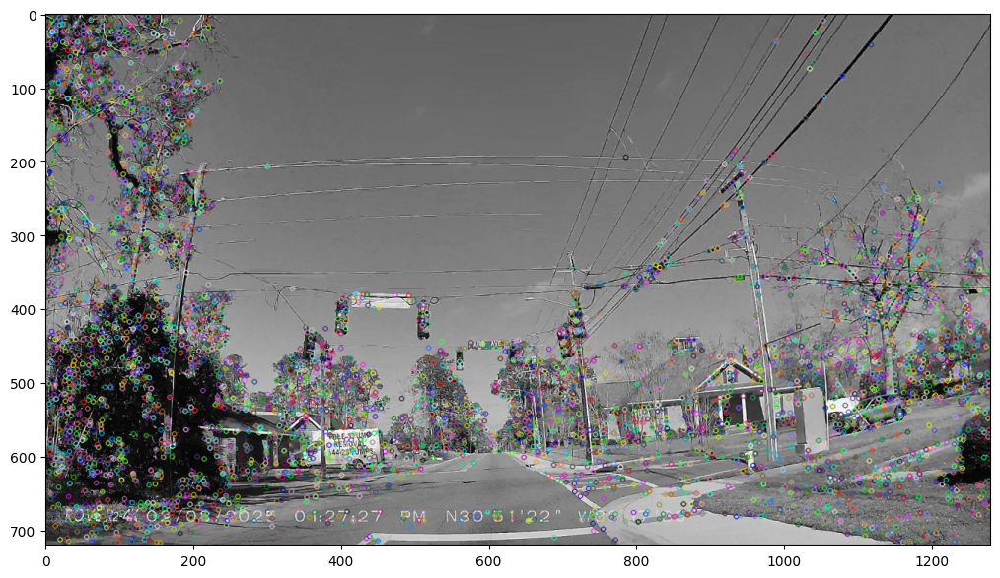

In [8]:
img1 = cv2.imread('data/escena_1.jpg')  
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

#keypoints
sift = cv2.SIFT_create()
keypoints_1, descriptors_1 = sift.detectAndCompute(img1,None)

img_1 = cv2.drawKeypoints(gray1,keypoints_1,img1)
plt.imshow(img_1)

### Matching different images

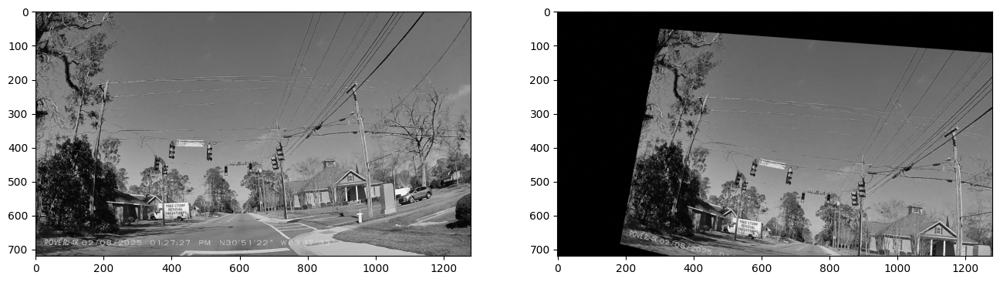

In [9]:
# read images
img1 = cv2.imread('data/escena_1.jpg')  
img2 = cv2.imread('data/escena_2.png') 

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

figure, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].imshow(img1, cmap='gray')
ax[1].imshow(img2, cmap='gray')

### Extracting Keypoints with SIFT

In [10]:
#sift
sift = cv2.SIFT_create()

keypoints_1, descriptors_1 = sift.detectAndCompute(img1,None)
keypoints_2, descriptors_2 = sift.detectAndCompute(img2,None)

len(keypoints_1), len(keypoints_2)

(4865, 3984)

### Feature Matching

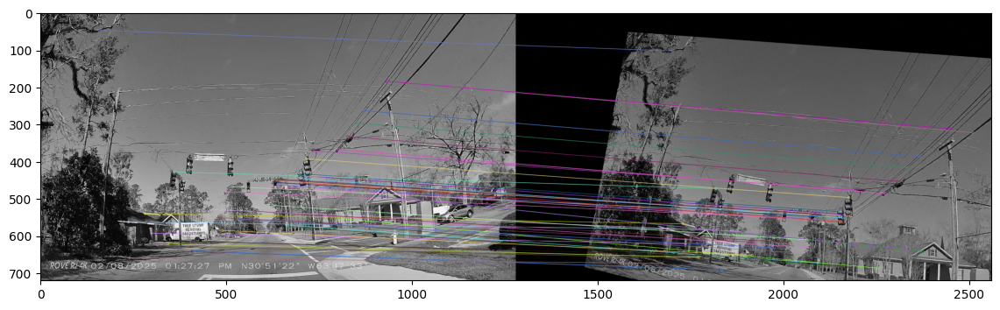

(<matplotlib.image.AxesImage at 0x16133fb1e50>, None)

In [11]:
#feature matching
bf = cv2.BFMatcher(cv2.NORM_L1, crossCheck=True)

matches = bf.match(descriptors_1,descriptors_2)
matches = sorted(matches, key = lambda x:x.distance)

img3 = cv2.drawMatches(img1, keypoints_1, img2, keypoints_2, matches[:50], img2, flags=2)
plt.imshow(img3),plt.show()

# Experimentos: qué tan buenos son los descriptores para el matching

La actividad pide probar diferentes descriptores con variaciones de **iluminación** y **orientación**, y ver qué tan bien funciona el matching **con Harris por sí solo** o con otros como **SIFT** y **ORB**.
Como las dos fotos de personas del notebook base (`elon_1`, `elon_2`) no se incluyeron, se usa una escena urbana real (CC0) y se generan vistas con transformación conocida (`puntos.py`), de modo que cada correspondencia se puede calificar como correcta o errónea.

Se comparan tres alternativas, todas con la misma prueba de razón de Lowe (0.8) y 1500 puntos como máximo:

| Método | Detector | Descriptor | Distancia |
|---|---|---|---|
| **Harris + parche** | esquinas de Harris | parche 17×17 normalizado (media 0, norma 1) | L2 |
| **ORB** | FAST orientado | BRIEF binario girado | Hamming |
| **SIFT** | diferencia de gaussianas (invariante a escala) | histogramas de gradientes (128 valores) | L2 |

«Harris por sí solo» no tiene descriptor propio: describe únicamente *dónde* hay esquinas; aquí se le da el descriptor más sencillo posible (el parche de píxeles) para emparejarlo.

In [12]:
import numpy as np, cv2, matplotlib.pyplot as plt
import puntos as P
plt.rcParams.update({"font.size": 9})

escena = cv2.imread("data/escena_1.jpg")
h, w = escena.shape[:2]
FOCO = 900
def rot(**kw): return P.homografia_rotacion(w, h, FOCO, **kw)
I = np.eye(3)
condiciones = {
    "sin cambio":                          (I, {}),
    "poca luz (×0.3)":                     (I, dict(brillo=0.3)),
    "sobreexpuesta (γ=0.5, ×1.5)":         (I, dict(gamma=0.5, brillo=1.5)),
    "bajo contraste + ruido":              (I, dict(brillo=0.45, offset=70, ruido=8)),
    "giro 30° (roll)":                     (rot(roll=30), {}),
    "giro 90° (roll)":                     (rot(roll=90), {}),
    "perspectiva yaw 25°":                 (rot(yaw=25), {}),
    "escala 0.6×":                         (P.homografia_rotacion(w, h, FOCO, escala=0.6), {}),
    "giro 30° + poca luz":                 (rot(roll=30), dict(brillo=0.3)),
}
metodos = ["harris", "orb", "sift"]
res = {}
for n, (H, kw) in condiciones.items():
    v = P.vista(escena, H, **kw)
    for m in metodos:
        res[(n, m)] = P.evaluar(escena, v, H, m, n=1500, ratio=0.8)[0]
print("CORRESPONDENCIAS CORRECTAS (de las totales), precisión y matches consistentes con la homografía estimada (RANSAC)\n")
print(f"{'condición':30s} " + " ".join(f"{m:>25s}" for m in metodos))
for n in condiciones:
    print(f"{n:30s} " + " ".join(f"{res[(n, m)]['correctos']:5d}/{res[(n, m)]['matches']:<5d} {res[(n, m)]['precision']*100:5.1f}% RS{res[(n, m)]['inliers_ransac']:<5d}" for m in metodos))

CORRESPONDENCIAS CORRECTAS (de las totales), precisión y matches consistentes con la homografía estimada (RANSAC)

condición                                         harris                       orb                      sift
sin cambio                      1357/1357  100.0% RS1357   1500/1500  100.0% RS1500   1500/1500  100.0% RS1500 
poca luz (×0.3)                 1293/1296   99.8% RS1293   1285/1309   98.2% RS1285   1215/1226   99.1% RS1215 
sobreexpuesta (γ=0.5, ×1.5)      323/327    98.8% RS323     184/219    84.0% RS182     262/284    92.3% RS262  
bajo contraste + ruido           931/939    99.1% RS931    1254/1271   98.7% RS1254    878/896    98.0% RS878  
giro 30° (roll)                    0/5       0.0% RS4       786/827    95.0% RS787     837/856    97.8% RS837  
giro 90° (roll)                    0/3       0.0% RS0       567/624    90.9% RS582     651/662    98.3% RS651  
perspectiva yaw 25°              219/227    96.5% RS219     522/555    94.1% RS519     546/574    95.1% 

In [13]:
print("REPETIBILIDAD DEL DETECTOR (%) y TIEMPO (ms, detección en las dos imágenes)\n")
print(f"{'condición':30s} " + " ".join(f"{m:>18s}" for m in metodos))
for n in condiciones:
    print(f"{n:30s} " + " ".join(f"{res[(n, m)]['repetibilidad']*100:8.1f}% {res[(n, m)]['t_deteccion_ms']:6.0f}ms" for m in metodos))
print("\nError medio de la homografía estimada (px, en las 4 esquinas; NaN si RANSAC no encontró modelo)\n")
print(f"{'condición':30s} " + " ".join(f"{m:>10s}" for m in metodos))
for n in condiciones: print(f"{n:30s} " + " ".join(f"{res[(n, m)]['error_H_px']:10.2f}" for m in metodos))

REPETIBILIDAD DEL DETECTOR (%) y TIEMPO (ms, detección en las dos imágenes)

condición                                  harris                orb               sift
sin cambio                        100.0%     57ms    100.0%     23ms    100.0%    108ms
poca luz (×0.3)                    96.4%     48ms     94.2%     17ms     83.6%    103ms
sobreexpuesta (γ=0.5, ×1.5)        45.9%     47ms     49.2%     24ms     34.1%    106ms
bajo contraste + ruido             81.1%     47ms     95.9%     19ms     68.7%    118ms
giro 30° (roll)                    73.5%     92ms     85.3%     21ms     82.0%    120ms
giro 90° (roll)                    99.6%     43ms     85.9%     27ms     95.8%    116ms
perspectiva yaw 25°                64.2%     45ms     91.7%     30ms     67.0%    108ms
escala 0.6×                        32.7%     52ms     89.5%     19ms     35.2%    111ms
giro 30° + poca luz                73.1%     47ms     81.8%     17ms     65.4%    128ms

Error medio de la homografía estimada (px,

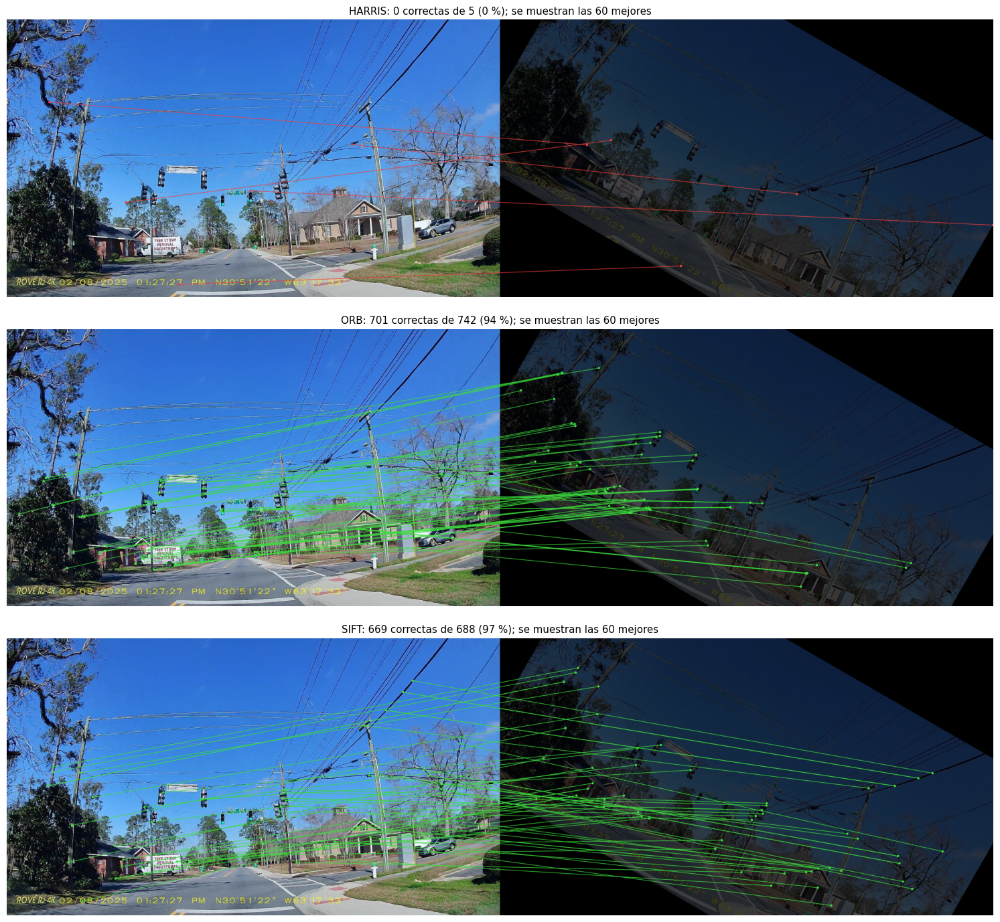

In [14]:
# Visualización: giro de 30° con poca luz (el caso más difícil de la tabla). Verde = correspondencia correcta, rojo = errónea.
H, kw = condiciones["giro 30° + poca luz"]
v = P.vista(escena, H, **kw)
fig, ejes = plt.subplots(3, 1, figsize=(15, 14))
for a, m in zip(ejes, metodos):
    r, (k1, k2, ms) = P.evaluar(escena, v, H, m, n=1500, ratio=0.8)
    a.imshow(cv2.cvtColor(P.dibujar_matches(escena, k1, v, k2, ms, H, max_n=60), cv2.COLOR_BGR2RGB))
    a.set_title(f"{m.upper()}: {r['correctos']} correctas de {r['matches']} ({r['precision']*100:.0f} %); se muestran las 60 mejores"); a.axis("off")
plt.tight_layout(); plt.show()

## Hallazgos


**Cambios de iluminación (sin cambiar la geometría).**
- Con poca luz (×0.3) los tres funcionan casi igual: Harris 1293/1296 correctas (99.8 %), ORB 1285/1309 (98.2 %) y SIFT 1215/1226 (99.1 %). Con bajo contraste y ruido, todos superan el 98 %.
- La **sobreexposición con saturación** es el caso más difícil de los cambios fotométricos: Harris conserva la precisión (98.8 %) pero con muy pocas correspondencias (323), SIFT baja a 92.3 % (262/284) y **ORB a 84.0 %** (184/219). Los descriptores binarios de ORB comparan pares de píxeles y se confunden cuando las zonas saturadas pierden textura.

**Cambios de orientación y escala.**
- **Harris por sí solo no sirve con giros**: con 30° solo produce 5 correspondencias y ninguna es correcta (0/5), y con 90° solo 3 (0/3). El descriptor de parche compara los píxeles tal como están y no es invariante a la rotación; el detector encuentra las mismas esquinas (repetibilidad de 73.5 % con 30° y 99.6 % con 90°, donde el giro exacto no interpola), pero no hay cómo reconocerlas. Con la escala de 0.6× solo logra 11/17.
- **ORB y SIFT funcionan con giros y escala**: con 30° ORB 786/827 (95.0 %) y SIFT 837/856 (97.8 %); con 90° ORB 567/624 (90.9 %) y SIFT 651/662 (98.3 %); con escala 0.6× ORB 519/534 (97.2 %) y SIFT 243/256 (94.9 %). Combinar giro y poca luz (30° + ×0.3) no cambia esa conclusión (ORB 94.5 %, SIFT 97.2 %).
- Con una **perspectiva moderada (yaw 25°)** hasta el parche de Harris sirve (219/227, 96.5 %), pero con menos correspondencias que ORB (522) o SIFT (546).

**Precisión geométrica y tiempo.**
- SIFT es el más preciso: el error de la homografía estimada (RANSAC) no supera 0.51 px en ninguna condición. ORB llega a errores de entre 0.05 y 7.6 px (el peor caso, con la perspectiva de 25°). Con solo 4 o 5 correspondencias, la homografía de Harris no tiene sentido (errores de cientos de píxeles).
- En tiempo de detección (dos imágenes de 1280×720, un solo equipo y varias ejecuciones), ORB fue el más rápido (unos 20–40 ms), Harris quedó en un punto intermedio (45–110 ms) y SIFT fue el más lento (105–220 ms), varias veces más que ORB (entre 3 y 8 veces según la condición). Los valores exactos cambian de una ejecución a otra, pero el orden se mantuvo.

**Conclusiones.** (1) Harris detecta *dónde* hay puntos estables; para emparejar hace falta un descriptor, y con uno ingenuo (píxeles del parche) no soporta rotación ni escala. (2) SIFT ofrece la mejor precisión y la mayor robustez, a cambio de tiempo de cómputo; ORB es una alternativa mucho más rápida con precisión ligeramente menor, salvo con saturación. (3) Ninguno resolvió sin errores la saturación de luces. (4) Los resultados dependen de la escena y de la prueba de razón (0.8); son de una sola escena con vistas sintéticas y deberían complementarse con fotos reales propias.


## Referencias

- Harris, C., & Stephens, M. (1988). A combined corner and edge detector. En *Proceedings of the 4th Alvey Vision Conference* (pp. 147–151). Alvey Vision Club.
- Lowe, D. G. (2004). Distinctive image features from scale-invariant keypoints. *International Journal of Computer Vision, 60*(2), 91–110. https://doi.org/10.1023/B:VISI.0000029664.99615.94
- Rublee, E., Rabaud, V., Konolige, K., & Bradski, G. (2011). ORB: An efficient alternative to SIFT or SURF. En *2011 International Conference on Computer Vision* (pp. 2564–2571). IEEE. https://doi.org/10.1109/ICCV.2011.6126544
- Fischler, M. A., & Bolles, R. C. (1981). Random sample consensus: A paradigm for model fitting with applications to image analysis and automated cartography. *Communications of the ACM, 24*(6), 381–395. https://doi.org/10.1145/358669.358692
- Mikolajczyk, K., & Schmid, C. (2005). A performance evaluation of local descriptors. *IEEE Transactions on Pattern Analysis and Machine Intelligence, 27*(10), 1615–1630. https://doi.org/10.1109/TPAMI.2005.188
- OpenCV. (s. f.). *Feature detection and description*. https://docs.opencv.org/4.x/db/d27/tutorial_py_table_of_contents_feature2d.html
- Imágenes: ver `LICENCIAS.md` (Wikimedia Commons, M. Rivera, CC0).